# Projet de fin de formation – Data Analyst

## Analyse exploratoire (EDA)

### Jeu de données : TheLook Ecommerce

Périmètre :
- France
- Produits Femme
- Années 2023 et 2024

In [1]:
%pip install pandas numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("../data/thelook_fr_women_2023_2024.csv")

In [5]:
df.head()

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.500000,16.048000,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.000000,10.000000,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
2,4710,6730,11792,2023-01-03 04:44:50+00:00,Complete,38.000000,18.468000,Intimates,Women,American Apparel,American Apparel Striped Chiffon Tank,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
3,16618,24006,329,2023-01-03 15:13:39+00:00,Complete,27.990000,16.402140,Tops & Tees,Women,Tri-Mountain,Tri-Mountain Women's 3/4-Sleeve Pique Knit Pol...,Complete,2023-01-03 18:58:00+00:00,2023-01-05 13:23:00+00:00,2023-01-09 10:25:00+00:00,13422,F,France,Hauts-de-France,Comines
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.880001,29.577601,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris


In [7]:
print(f"Ce dataset est composé de : \n{df.shape[0]} lignes\n{df.shape[1]} colonnes")

Ce dataset est composé de : 
1679 lignes
20 colonnes


## Dictionnaire des colonnes

In [11]:
print(f"Informations sur le type des colonnes du dataset:")
print(df.info())

Informations sur le type des colonnes du dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   str    
 4   item_status       1679 non-null   str    
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   str    
 8   department        1679 non-null   str    
 9   brand             1677 non-null   str    
 10  product_name      1679 non-null   str    
 11  order_status      1679 non-null   str    
 12  order_created_at  1679 non-null   str    
 13  shipped_at        1133 non-null   str    
 14  delivered_at      636 non-null    str    
 15  user_id           1679 non-null   int64  
 16  gen

In [12]:
print(f"Valeurs vides du dataset:")
print(df.isna().sum())

Valeurs vides du dataset:
order_id               0
order_item_id          0
product_id             0
item_created_at        0
item_status            0
sale_price             0
cost                   0
category               0
department             0
brand                  2
product_name           0
order_status           0
order_created_at       0
shipped_at           546
delivered_at        1043
user_id                0
gender                 0
country                0
state                  0
city                   0
dtype: int64


In [9]:
print(f"Statistiques du dataset :")
print(df.describe())

Statistiques du dataset :
            order_id  order_item_id    product_id   sale_price         cost  \
count    1679.000000    1679.000000   1679.000000  1679.000000  1679.000000   
mean    60851.683740   88372.698035   7922.506254    57.021769    27.460066   
std     35655.502994   51820.578196   4680.553838    69.682245    31.854450   
min       359.000000     517.000000     12.000000     1.820000     0.749840   
25%     30357.000000   44069.500000   3812.000000    19.990000     9.681000   
50%     60827.000000   88353.000000   7907.000000    38.000000    18.230800   
75%     90911.000000  132106.000000  12053.000000    68.000000    33.232345   
max    124791.000000  181230.000000  15982.000000   903.000000   437.052001   

            user_id  
count   1679.000000  
mean   48702.836212  
std    28441.847629  
min      279.000000  
25%    24349.000000  
50%    48715.000000  
75%    72541.000000  
max    99717.000000  


In [37]:
print("Valeurs manquantes :\n")
valeurmanquante = df.isna().sum()
print(valeurmanquante[valeurmanquante>0])

Valeurs manquantes :

brand              2
shipped_at       546
delivered_at    1043
dtype: int64


## Contrôle qualité

In [ ]:
print("Présence de doublon\n Seules seront pris en compte les colonnes order_id et order_item_id \n") 

colonneorder = df[["order_id","order_item_id"]]
valeurendouble=[]
for valboucle in colonneorder:
    nb_unique=df[valboucle].nunique()
    nb_doublon = df[valboucle].duplicated().sum()
    valeurendouble.append({'colonne':valboucle, 'nombre':nb_unique, 'type':'unique'})
    valeurendouble.append({'colonne':valboucle, 'nombre':nb_doublon,'type':'doublon'})

dfdoublon =pd.DataFrame(valeurendouble)
print(dfdoublon)
print("\n")
print(f"Ce qui indique que :\n un order_item_id est unique \n un order_id peut être contenir un ou plusieurs order_item_id")
print("\n")
print("Les autres colonnes de ce dataset présentent des doublons logiques de base de données")
print(f"Exemple: item_status, les valeurs de cette colonne sont prédéfinies ce qui implique nécessairement des doublons")

Présence de doublon
 Seules seront pris en compte les colonnes order_id et order_item_id 

         colonne  nombre     type
0       order_id    1117   unique
1       order_id     562  doublon
2  order_item_id    1679   unique
3  order_item_id       0  doublon


Ce qui indique que :
 un order_item_id est unique 
 un order_id peut être associé à un ou plusieurs order_item_id


Les autres colonnes de ce dataset présentent des doublons logiques de base de données
Exemple: item_status, les valeurs de cette colonne sont prédéfinies ce qui implique nécessairement des doublons


In [4]:
print("Conversion/transformation des colonnes dates :")
print(f"Format des colonnes :")
print(df[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes)

df["item_created_at"] = pd.to_datetime(df["item_created_at"])
df["order_created_at"] = pd.to_datetime(df["order_created_at"])
df["shipped_at"] = pd.to_datetime(df["shipped_at"])
df["delivered_at"] = pd.to_datetime(df["delivered_at"])

print(f"Format des colonnes après transformation:")
print(df[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes)


Conversion/transformation des colonnes dates :
Format des colonnes :
item_created_at     str
order_created_at    str
shipped_at          str
delivered_at        str
dtype: object
Format des colonnes après transformation:
item_created_at     datetime64[us, UTC]
order_created_at    datetime64[us, UTC]
shipped_at          datetime64[us, UTC]
delivered_at        datetime64[us, UTC]
dtype: object


In [5]:
#Ajout au dataframe les colonnes mois et année

df["numero_mois"]=df["order_created_at"].dt.month

df["mois"]=df["numero_mois"].map({
    1: "Janvier",
    2: "Février",
    3: "Mars",
    4: "Avril",
    5: "Mai",
    6: "Juin",
    7: "Juillet",
    8: "Août",
    9: "Septembre",
    10: "Octobre",
    11: "Novembre",
    12: "Décembre"
})

df["annee"]=df["order_created_at"].dt.year


In [ ]:
print(f"Temporalité du dataset brut (order_created_at):\n")
print(f"Début : {df["order_created_at"].min()}")
print(f"au : {df["order_created_at"].max()}")


Temporalité du dataset brut (order_created_at):

Début : 2022-12-29 10:00:00+00:00

au : 2024-12-31 05:13:00+00:00


In [ ]:
print(f"\nCe datatset contient les 3 derniers jours de l'année 2022")
print(f"Les informations concernant cette année 2022 seront supprimées du dataset")

df = df.query("annee != 2022")

print(f"Début : {df["order_created_at"].min()}")
print(f"au : {df["order_created_at"].max()}")



Ce datatset contient les 3 derniers jours de l'année 2022
Les informations concernant cette année 2022 seront supprimées du dataset
Début : 2023-01-03 08:12:00+00:00

au : 2024-12-31 05:13:00+00:00


In [ ]:
print(f"Temporalité par année:")
df2023 = df.query("annee == 2023")
print(f"Début 2023: {df2023["order_created_at"].min()}")
print(f"Fin 2023: {df2023["order_created_at"].max()}\n")

df2024 = df.query("annee == 2024")
print(f"Début 2024: {df2024["order_created_at"].min()}")
print(f"Fin 2024: {df2024["order_created_at"].max()}\n")


Temporalite par année:
Début 2023: 2023-01-03 08:12:00+00:00
Fin 2023: 2023-12-31 18:49:00+00:00

Début 2024: 2024-01-02 13:08:00+00:00
Fin 2024: 2024-12-31 05:13:00+00:00



In [43]:
print(f"Cohérence entre date de création de l'ordre et date d'envoi")
incoherence = df[df["order_created_at"] > df["shipped_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print("\n")
print(f"Cohérence entre date de création de l'ordre et date de livraison")
incoherence = df[df["order_created_at"] > df["delivered_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print("\n")
print(f"Cohérence entre date de création de l'ordre et date de création de l'item")
incoherence = df[df["order_created_at"] > df["item_created_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print(f"Ce qui indique que certaines commandes ont une date de création postérieur aux lignes de commande")


Cohérence entre date de création de l'ordre et date d'envoi
0 incohérence(s)


Cohérence entre date de création de l'ordre et date de livraison
0 incohérence(s)


Cohérence entre date de création de l'ordre et date de création de l'item
904 incohérence(s)
Ce qui indique que certaines commandes ont une date de création postérieur aux lignes de commande


## Analyse descriptive

In [44]:
prixmedian=df["sale_price"].mean().round(2)
print(f"Prix de vente médian : {prixmedian}")
coutmedian=df["cost"].mean().round(2)
print(f"Coût médian : {coutmedian}")

Prix de vente médian : 57.06
Coût médian : 27.48


In [45]:
print(f"Explorations descriptives : distributions (prix de vente, coût)")
print(df[["sale_price", "cost"]].describe())

Explorations descriptives : distributions (prix de vente, coût)
        sale_price         cost
count  1677.000000  1677.000000
mean     57.060256    27.477283
std      69.714693    31.869373
min       1.820000     0.749840
25%      19.990000     9.666000
50%      38.000000    18.240000
75%      68.000000    33.275839
max     903.000000   437.052001


## Calcul des KPI

In [ ]:
def contribution(df, varexplodescrip):
    """
        df_tcd :
        définition d'un tcd qui aura index en variable. 
        ce dataframe prendra en compte toutes les valeurs du champ order_status (Cancelled,Processing,Complete...)
        Cette variable sera définit comme suit: catégorie,marque, ville
        Le choix de la variable ne sera pas demandé à l'utilisateur.
        Cette fonction sera appelée pour chacune des variables
        
        df_tcdcompleted :
        identique à df_tcd mais filtré sur order_status = 'Complete' (voir le dataframe df_completed)

        df_analyse :
        sera une concatenation des deux précédents dataframe
        ce qui donnera une vision nombre de ventes et ca fictif vs nombre de ventes et ca réel
        A partir de df_analyse : calcul du top 5 / flop 5 avec nombre de ventes et le ca associé
    """

    # Toutes les commandes
    df_tcd = df.pivot_table(
        index=varexplodescrip,
        values="sale_price",
        aggfunc=["count", "sum"]
    )

    df_tcd.columns = ["nb_ventes", "ca"]
    df_tcd["ca"] = df_tcd["ca"].round(2)

    # Commandes réelles
    df_completed = df.query("order_status == 'Complete'")

    df_tcdcompleted = df_completed.pivot_table(
        index=varexplodescrip,
        values="sale_price",
        aggfunc=["count", "sum"]
    )

    df_tcdcompleted.columns = ["nb_ventes_reel", "ca_reel"]
    df_tcdcompleted["ca_reel"] = df_tcdcompleted["ca_reel"].round(2)

    # jointure des deux dataframes
    df_analyse = df_tcd.join(df_tcdcompleted, how="left")

    # Remplacement des valeurs manquantes
    df_analyse[["nb_ventes_reel", "ca_reel"]] = (
        df_analyse[["nb_ventes_reel", "ca_reel"]].fillna(0)
    )

    df_analyse["nb_ventes_reel"] = (
        df_analyse["nb_ventes_reel"].astype(int)
    )

    # Top selon le CA total
    df_top = df_analyse.sort_values(
        "ca",
        ascending=False
    ).head(5)

    # Flop selon le CA total 
    df_flop = df_analyse.sort_values(
        "ca",
        ascending=True
    ).head(5)

    return {
        "tcd": df_analyse,
        "top": df_top,
        "flop": df_flop
    }

In [43]:
print("Volume de commande potentiel vs réel par catégorie (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df, "category")

print("Top 5")
print(resultat["top"])

print("\nFlop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par catégorie (trié par ca)
Rappel : réel = order_status : Complete

Top 5
                   nb_ventes        ca  nb_ventes_reel  ca_reel
category                                                       
Outerwear & Coats         60  10073.57              14  3147.65
Dresses                  109   9355.12              19  1340.65
Jeans                     88   8618.09              18  2023.56
Intimates                246   8220.94              72  2259.31
Swim                      90   6253.95              22  1267.04

Flop 5
                     nb_ventes       ca  nb_ventes_reel  ca_reel
category                                                        
Clothing Sets                2   183.99               0     0.00
Jumpsuits & Rompers         16   829.67               5   139.42
Socks & Hosiery             62   973.55              17   300.31
Leggings                    53  1146.33              17   406.39
Suits                       18  1759.54   

In [44]:
print("Volume de commande potentiel vs réel par marque (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df,"brand")

print(f"Top 5")
print(resultat["top"])
print("\n")
print(f"Flop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par marque (trié par ca)
Rappel : réel = order_status : Complete

Top 5
                   nb_ventes       ca  nb_ventes_reel  ca_reel
brand                                                         
The North Face             7  2711.99               2  1211.00
Jones New York            18  2386.48               4   516.99
7 For All Mankind         13  2124.49               0     0.00
Calvin Klein              25  1851.35               5   292.00
Ray-Ban                   13  1722.78               3   479.90


Flop 5
                  nb_ventes    ca  nb_ventes_reel  ca_reel
brand                                                     
Star                      1  1.82               1     1.82
Skyblue                   1  2.99               0     0.00
Scarf_tradinginc          1  3.17               1     3.17
Greatlookz                1  3.50               1     3.50
Locs                      1  3.70               0     0.00


In [45]:
print("Volume de commande potentiel vs réel par ville (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df,"city")

print(f"Top 5")
print(resultat["top"])
print("\n")
print(f"Flop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par ville (trié par ca)
Rappel : réel = order_status : Complete

Top 5
                        nb_ventes       ca  nb_ventes_reel  ca_reel
city                                                               
Paris                          94  4762.09              25   949.83
Marseille                      25  2296.68               7   260.70
Lyon                           23  1080.81               8   536.44
Caluire-et-Cuire                9  1012.85               0     0.00
Sainte-Gemme-la-Plaine         11   987.88               3   143.99


Flop 5
                            nb_ventes    ca  nb_ventes_reel  ca_reel
city                                                                
Noyal-Châtillon-sur-Seiche          1  3.11               1     3.11
Saint-Martin-d'Hères                1  3.28               0     0.00
Cambrai                             1  5.95               0     0.00
Amilly                              1  6.00               1   

Saisonnalité mensuelle
                       nb_ventes            ca
numero_mois mois                              
1           Janvier          111   6125.910012
2           Février          120   6269.369999
3           Mars             108   4584.579976
4           Avril            126   7476.410015
5           Mai              125   7571.660010
6           Juin             159   9337.400027
7           Juillet          122   5929.830009
8           Août             144   8144.600004
9           Septembre        165   9898.720007
10          Octobre          150  11823.710015
11          Novembre         167   8608.830030
12          Décembre         180   9919.030035

 Graphique:


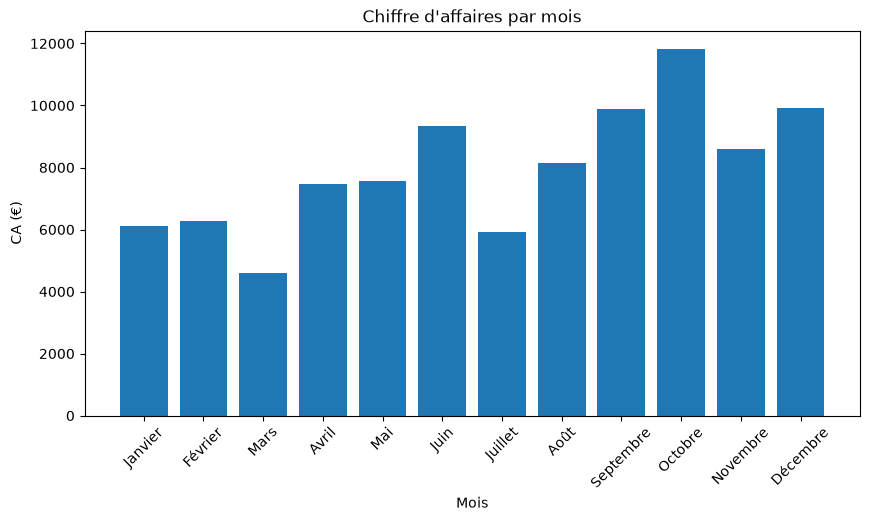

In [50]:
df_tcd2 = df.pivot_table(
    index=["numero_mois","mois"],
    values="sale_price",
    aggfunc=["count", "sum"]
)
df_tcd2.columns = ["nb_ventes", "ca"]

print(f"Saisonnalité mensuelle")
print(df_tcd2)
print("\n Graphique:")

plt.figure(figsize=(10, 5))

plt.bar(
    df_tcd2.index.get_level_values("mois"),
    df_tcd2["ca"]
)

plt.title("Chiffre d'affaires par mois")
plt.xlabel("Mois")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)

plt.show()

## Comparaison 2023 / 2024

In [51]:
print(f"Comparaison 2023 vs 2024\n")
ordre = [
    "Janvier", "Février", "Mars", "Avril", "Mai", "Juin",
    "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"
]
dfventes=df.groupby(["annee","mois"])["sale_price"].sum().round(2).unstack(0).reindex(ordre)
dfventes.columns = ["2023", "2024"]
print(dfventes.head(12))


Comparaison 2023 vs 2024

              2023     2024
mois                       
Janvier    2315.51  3810.40
Février    2621.73  3647.64
Mars       2241.82  2342.76
Avril      4050.46  3425.95
Mai        3422.95  4148.71
Juin       3833.69  5503.71
Juillet    1959.97  3969.86
Août       3402.48  4742.12
Septembre  4446.08  5452.64
Octobre    5216.54  6607.17
Novembre   2871.21  5737.62
Décembre   4399.40  5519.63


In [52]:
#Ajout des colonnes écarts absolus et écarts relatifs
dfventes["ecartrelatif"] = (
    ((dfventes["2024"] - dfventes["2023"]) / dfventes["2023"]) * 100).round(2)

dfventes["ecartabsolu"] = (dfventes["2024"] - dfventes["2023"]).round(2)
print(dfventes.head(12))

              2023     2024  ecartrelatif  ecartabsolu
mois                                                  
Janvier    2315.51  3810.40         64.56      1494.89
Février    2621.73  3647.64         39.13      1025.91
Mars       2241.82  2342.76          4.50       100.94
Avril      4050.46  3425.95        -15.42      -624.51
Mai        3422.95  4148.71         21.20       725.76
Juin       3833.69  5503.71         43.56      1670.02
Juillet    1959.97  3969.86        102.55      2009.89
Août       3402.48  4742.12         39.37      1339.64
Septembre  4446.08  5452.64         22.64      1006.56
Octobre    5216.54  6607.17         26.66      1390.63
Novembre   2871.21  5737.62         99.83      2866.41
Décembre   4399.40  5519.63         25.46      1120.23


In [53]:
print(f"Les ruptures 2023-2024")
print("Pic")
print("2023 :", dfventes["2023"].idxmax(), "-", dfventes["2023"].max())
print("2024 :", dfventes["2024"].idxmax(), "-", dfventes["2024"].max())
print("\nCreux")
print("2023 :", dfventes["2023"].idxmin(), "-", dfventes["2023"].min())
print("2024 :", dfventes["2024"].idxmin(), "-", dfventes["2024"].min())

print("\nPlus forte hausse :")
print(dfventes["ecartrelatif"].idxmax(), " ", dfventes["ecartrelatif"].max(), "%")

print("\nPlus forte baisse :")
print(dfventes["ecartrelatif"].idxmin(), " ", dfventes["ecartrelatif"].min(), "%")


Les ruptures 2023-2024
Pic
2023 : Octobre - 5216.54
2024 : Octobre - 6607.17

Creux
2023 : Juillet - 1959.97
2024 : Mars - 2342.76

Plus forte hausse :
Juillet   102.55 %

Plus forte baisse :
Avril   -15.42 %


Visualisation



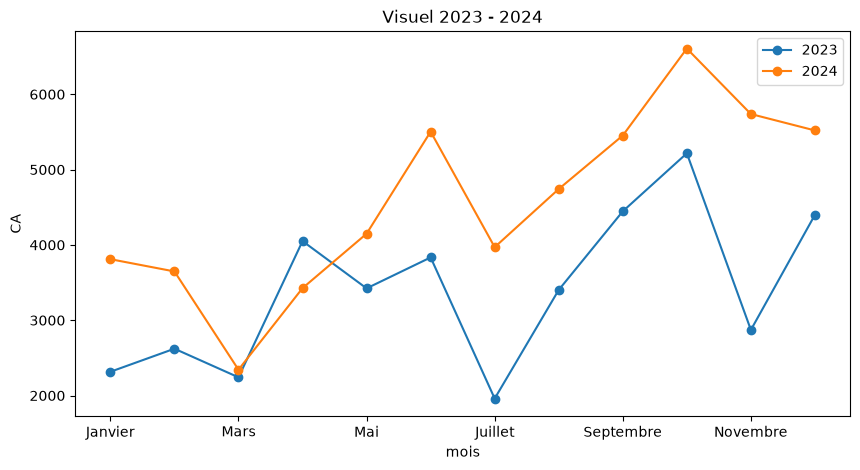

In [55]:
print(f"Visualisation\n")
dfventes[["2023","2024"]].plot(marker = "o",figsize=(10,5))
plt.title("Visuel 2023 - 2024")
plt.xlabel("mois")
plt.ylabel("CA")
plt.show()


In [13]:
dfta = df.groupby("user_id")["order_id"].nunique().reset_index(name="nb_order_id")
#print(df.groupby("user_id")["order_id"].nunique())
#print(dfta.head())
print(dfta.query("nb_order_id >=2")) 

     user_id  nb_order_id
2        883            2
12      2083            2
20      2536            3
25      2835            3
30      3055            3
..       ...          ...
849    98035            3
854    98798            2
857    98817            2
861    99288            2
867    99717            2

[196 rows x 2 columns]


## Synthèse 2023 / 2024

In [57]:
def kpi(df, lannee):
    """
    création d'un dataframe filtré sur les status considérés comme vente et l'année en critères sélectionnable
    Chiffre d’affaires (somme de sale_price pour les lignes de vente).
    Marge brute (somme de sale_price – cost pour les lignes de vente).
    Panier moyen (CA / nombre de commandes avec revenu > 0).
    Taux de retour (part des lignes au statut Returned parmi les lignes vendues : ventes + retours).
    Taux de ré‑achat (part des clients ayant ≥ 2 commandes complètes sur une année).
    """
    dfkpi = df.query("order_status == 'Complete' & annee==@lannee")
    dftauxretour = df.query("(order_status == 'Complete' or order_status == 'Returned') & annee == @lannee")
    nbcommande = dfkpi.groupby("user_id")["order_id"].nunique()

    return {
        "df": dfkpi,
        "ca": dfkpi["sale_price"].sum(),
        "marge": (dfkpi["sale_price"] - dfkpi["cost"]).sum(),
        "panier": dfkpi["sale_price"].sum() / dfkpi["order_id"].nunique(),
        "taux_retour": ((dftauxretour["order_status"] == "Returned").mean() * 100),
        "taux_reachat": ((nbcommande>=2).sum() / nbcommande.count())*100
    }
while True:
    while True:
        lannee = int(input("Choisir une année (2023 ou 2024) : "))
        if lannee in [2023,2024]:
            break
        print("Année invalide. Veuillez saisir 2023 ou 2024.")

    resultat = kpi(df, lannee)
    print(f"Synthèse de l'année : {lannee}")
    print(f"{'INDICATEUR':<25}{'VALEUR':>25}")
    print("=" * 55)
    print(f"{'Chiffre d affaires':<25}{resultat['ca']:>25,.2f} €")
    print(f"{'Marge brute':<25}{resultat['marge']:>25,.2f} €")
    print(f"{'Panier moyen':<25}{resultat['panier']:>25,.2f} €")
    print(f"{'Taux de retour':<25}{resultat['taux_retour']:>24.2f} %")
    print(f"{'Taux de réachat':<25}{resultat['taux_reachat']:>24.2f} %")
    print("=" * 55)
    print("\n")

    #propose à l'utilisateur de choisir une autre année
    reponse = input("\nVoulez-vous faire un autre calcul ? (O/N) : ").strip().upper()
    if reponse != 'O':
        print(f"Calcul terminé")
        break


Synthèse de l'année : 2023
INDICATEUR                                  VALEUR
Chiffre d affaires                        7,806.32 €
Marge brute                               4,075.34 €
Panier moyen                                 80.48 €
Taux de retour                              37.87 %
Taux de réachat                              0.00 %


Synthèse de l'année : 2024
INDICATEUR                                  VALEUR
Chiffre d affaires                       15,716.28 €
Marge brute                               8,134.61 €
Panier moyen                                 85.41 €
Taux de retour                              30.42 %
Taux de réachat                              3.39 %


Calcul terminé
